# PHSX 256 Topic 9: Random Numbers and Random Number Generation in Python (NumPy)

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

Matplotlib is building the font cache; this may take a moment.



## What Are Random Numbers in a Computer?
Computers generate **pseudorandom** numbers using deterministic algorithms called **pseudorandom number generators (PRNGs)**. Given the same initial **seed**, a PRNG produces the same sequence of numbers—this is crucial for **reproducibility**.

In NumPy's modern RNG system:
- A **bit generator** (default: `PCG64`) produces raw random bits.
- A **Generator** (`np.random.default_rng(...)`) uses those bits to sample from distributions.

We'll primarily use the modern API: `rng = np.random.default_rng(seed)`. If you use the same seed and the same sequence of calls, you'll get identical results.



## Seeds and Reproducibility
A seed sets the initial state of the PRNG. Using the same seed leads to the same output stream.


In [2]:

# Choose a seed and create two independent Generators with the same seed
seed = 2024
rng1 = np.random.default_rng(seed)
rng2 = np.random.default_rng(seed)

# Draw some numbers from each and confirm equality
x1 = rng1.random(10)
x2 = rng2.random(10)

print("Are sequences identical? ", np.allclose(x1, x2))
print("x1:", x1)
print("x2:", x2)


Are sequences identical?  True
x1: [0.67583134 0.2143232  0.30945203 0.7994661  0.9958021  0.14223182
 0.07872553 0.18082381 0.35964689 0.16961925]
x2: [0.67583134 0.2143232  0.30945203 0.7994661  0.9958021  0.14223182
 0.07872553 0.18082381 0.35964689 0.16961925]



## Modern NumPy RNG vs Legacy API
The recommended API is the **Generator** class with `default_rng`. The older, legacy API uses module-level functions (`np.random.*`) and a global state. The modern API is:

- Explicit: you pass around a `Generator` instance (`rng`) instead of relying on global state.
- Easier to reason about in larger projects and simulations.

You'll still see the legacy API in older code. Here's how they compare:


In [3]:

# Modern API (recommended)
rng = np.random.default_rng(12345)
print("Modern uniform samples:", rng.uniform(0, 1, size=5))

# Legacy API (still works, but not recommended for new code)
np.random.seed(12345)
print("Legacy uniform samples:", np.random.uniform(0, 1, size=5))


Modern uniform samples: [0.22733602 0.31675834 0.79736546 0.67625467 0.39110955]
Legacy uniform samples: [0.92961609 0.31637555 0.18391881 0.20456028 0.56772503]



## Plotting Conventions
For continuous distributions, we'll plot **normalized histograms** (`density=True`) and overlay the analytic **PDF** (probability density function). For discrete distributions, we'll show a bar chart of counts normalized to probabilities and overlay the **PMF** (probability mass function).



## Uniform Distribution
If $X \sim U(a,b)$, then the PDF is

$ f(x) = \begin{cases}
\dfrac{1}{b-a}, & a \le x \le b \\
0, & \text{otherwise}
\end{cases} $

The mean and variance are $\mathbb{E}[X] = \dfrac{a+b}{2}$ and $\mathrm{Var}(X) = \dfrac{(b-a)^2}{12}$.



**Background and interpretation.** The continuous uniform distribution models a quantity that is equally likely to fall anywhere within a finite interval $[a,b]$. Its cumulative distribution function (CDF) is $F(x)=0$ for $x<a$, $F(x)=\dfrac{x-a}{b-a}$ for $a\le x\le b$, and $F(x)=1$ for $x>b$. It is often used to represent idealized measurement uncertainty or to serve as a base for **inverse-transform sampling** of other distributions. The $p$-quantile is $Q(p)=a+(b-a)p$. When simulating, remember that `rng.uniform(a,b)` samples on $[a,b)$ by default (the right endpoint is excluded), which is typically fine for continuous modeling. Units and dimensions carry through directly: if $x$ is a length, $a$ and $b$ must be in the same units.  
**Common physics uses.** Random initial phases, randomized start times within a cycle, or idealized “flat” priors over bounded parameters.


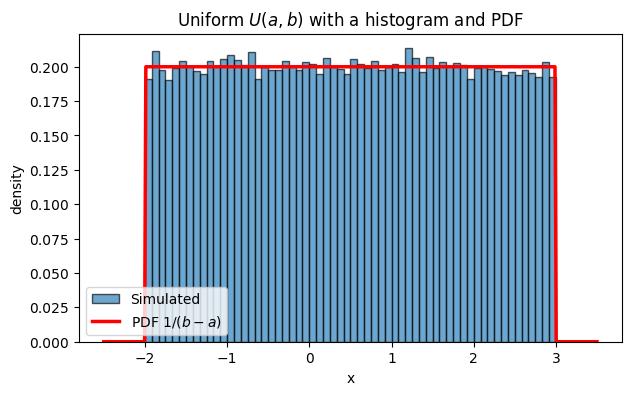

Sample mean: 0.4934 (theory 0.5000)
Sample variance: 2.0700 (theory 2.0833)


In [17]:

# Parameters
rng = np.random.default_rng(2024)
a, b = -2.0, 3.0
N = 100000

# Sample and basic stats
u = rng.uniform(low=a, high=b, size=N)
mean_sample = np.mean(u)
var_sample = np.var(u)

mean_theory = 0.5*(a+b)
var_theory = (b-a)**2/12

# Plot
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(u, bins=60, density=True, alpha=0.65, edgecolor='k', color='tab:blue', label='Simulated')

# Overlay PDF
xs = np.linspace(a-0.5, b+0.5, 400)
pdf = np.where((xs>=a)&(xs<=b), 1.0/(b-a), 0.0)
ax.plot(xs, pdf, 'r-', lw=2.5, label='PDF $1/(b-a)$')

ax.set_title('Uniform $U(a,b)$ with a histogram and PDF')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.legend()
plt.show()

print(f"Sample mean: {mean_sample:.4f} (theory {mean_theory:.4f})")
print(f"Sample variance: {var_sample:.4f} (theory {var_theory:.4f})")



## Normal (Gaussian) Distribution
If $X \sim \mathcal{N}(\mu, \sigma^2)$, then the PDF is

$ f(x) = \dfrac{1}{\sqrt{2\pi}\,\sigma} \exp\!\left(-\dfrac{(x-\mu)^2}{2\sigma^2}\right) $

The mean is $\mu$ and the variance is $\sigma^2$.



**Background and interpretation.** The normal distribution emerges naturally from the **Central Limit Theorem**: the sum (or average) of many small, independent effects tends toward a Gaussian, regardless of the details of each effect. Standardization maps $X$ to the $Z$-score via $Z=\dfrac{X-\mu}{\sigma}$. The CDF has no elementary closed form, but quantiles are tabulated and widely available numerically. The **68–95–99.7 rule** states that approximately $68\%$, $95\%$, and $99.7\%$ of mass lie within $\pm1\sigma$, $\pm2\sigma$, and $\pm3\sigma$ of the mean, respectively.  
**Composition and invariances.** Sums of independent Gaussians are Gaussian; linear transformations preserve normality. Independent $\mathcal{N}(0,\sigma^2)$ components produce isotropic Gaussian vectors in $\mathbb{R}^n$.  
**Common physics uses.** Thermal noise in electronics, measurement errors, beam profiles, and diffusion approximations where many random kicks accumulate.


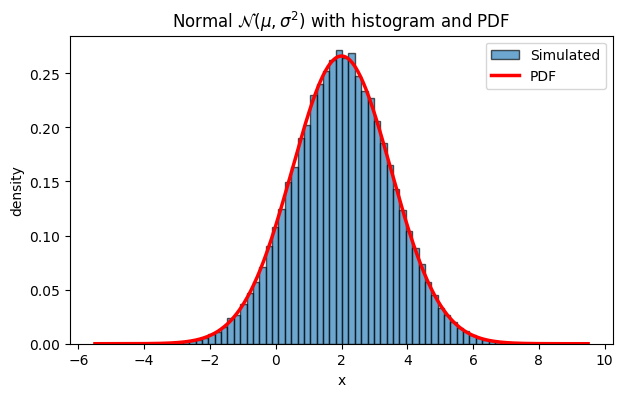

Sample mean: 2.0041 (theory 2.0000)
Sample variance: 2.2425 (theory 2.2500)


In [18]:

# Parameters
rng = np.random.default_rng(2024)
mu, sigma = 2.0, 1.5
N = 120000

# Sample and stats
x = rng.normal(loc=mu, scale=sigma, size=N)
mean_sample = np.mean(x)
var_sample = np.var(x)

# Plot
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(x, bins=70, density=True, alpha=0.65, edgecolor='k', color='tab:blue', label='Simulated')

xs = np.linspace(mu-5*sigma, mu+5*sigma, 600)
pdf = (1.0/(np.sqrt(2*np.pi)*sigma))*np.exp(-(xs-mu)**2/(2*sigma**2))
ax.plot(xs, pdf, 'r-', lw=2.5, label='PDF')

ax.set_title(r'Normal $\mathcal{N}(\mu, \sigma^2)$ with histogram and PDF')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.legend()
plt.show()

print(f"Sample mean: {mean_sample:.4f} (theory {mu:.4f})")
print(f"Sample variance: {var_sample:.4f} (theory {sigma**2:.4f})")



## Exponential Distribution
If $X \sim \mathrm{Exp}(\lambda)$, the PDF is

$ f(x) = \lambda e^{-\lambda x}, \quad x \ge 0 $

The mean is $\mathbb{E}[X] = 1/\lambda$ and the variance is $\mathrm{Var}(X) = 1/\lambda^2$.

In physics, exponential waiting times arise in memoryless processes like radioactive decay.



**Background and interpretation.** The exponential distribution models **waiting times** for events in a homogeneous **Poisson process** with constant rate $\lambda$; it is the unique **memoryless** continuous distribution: $P(X>t+s\mid X>t)=P(X>s)$. The survival function is $\bar F(x)=P(X>x)=e^{-\lambda x}$ and the CDF is $F(x)=1-e^{-\lambda x}$ for $x\ge0$. The hazard rate is constant and equal to $\lambda$.  
**Transformations and sums.** The minimum of independent exponentials is exponential with rate equal to the sum of the rates. The sum of $k$ i.i.d. (independent and identically distributed) exponentials has the **Gamma** distribution with shape $k$ and rate $\lambda$.  
**Common physics uses.** Radioactive decay, time between detection events (photons, cosmic rays), and relaxation processes with a single time constant.


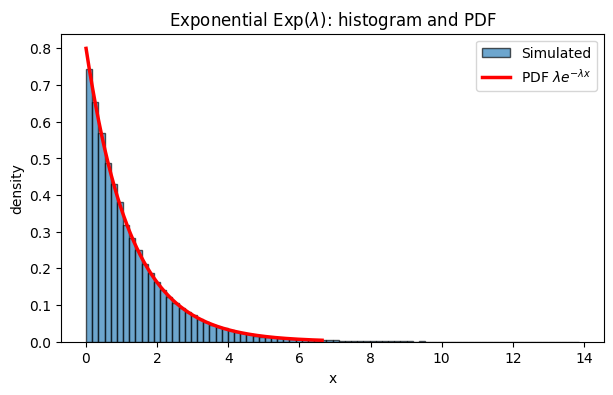

Sample mean: 1.2505 (theory 1.2500)
Sample variance: 1.5630 (theory 1.5625)


In [19]:

# Parameters
rng = np.random.default_rng(2024)
lmbda = 0.8  # rate parameter
N = 100000

# Sample and stats (NumPy's exponential uses 'scale' = 1/lambda)
exp_samples = rng.exponential(scale=1.0/lmbda, size=N)
mean_sample = np.mean(exp_samples)
var_sample = np.var(exp_samples)

# Plot
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(exp_samples, bins=80, density=True, alpha=0.65, edgecolor='k', color='tab:blue', label='Simulated')

xs = np.linspace(0, np.quantile(exp_samples, 0.995), 600)
pdf = lmbda*np.exp(-lmbda*xs)
ax.plot(xs, pdf, 'r-', lw=2.5, label=r'PDF $\lambda e^{-\lambda x}$')

ax.set_title(r'Exponential $\mathrm{Exp}(\lambda)$: histogram and PDF')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.legend()
plt.show()

print(f"Sample mean: {mean_sample:.4f} (theory {1/lmbda:.4f})")
print(f"Sample variance: {var_sample:.4f} (theory {(1/lmbda**2):.4f})")



## Poisson Distribution (Discrete)
If $K \sim \mathrm{Pois}(\lambda)$, then the PMF is

$ P(K=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}, \quad k=0,1,2,\dots $

The mean and variance are both $\lambda$. In physics, the Poisson distribution often models counts (e.g., photon counts per interval).



**Background and interpretation.** The Poisson distribution models the number of independent, rare events occurring in a fixed interval when events happen at an average rate $\lambda$ per interval. It can be derived as a **limit of the binomial**: if $K\sim\mathrm{Bin}(n,p)$ with $n\to\infty$ and $p\to0$ such that $np\to\lambda$, then $K$ converges in distribution to $\mathrm{Pois}(\lambda)$.  
**Properties.** $\mathbb{E}[K]=\lambda$ and $\mathrm{Var}(K)=\lambda$. Sums of independent Poisson variables are Poisson with parameter equal to the sum of the parameters. Inter-arrival times between events in a Poisson process are exponential; thus counts and waiting times are two sides of the same model.  
**Common physics uses.** Photon/electron counting, radioactive decay counts in a time bin, shot noise, and event detection in low-signal regimes.


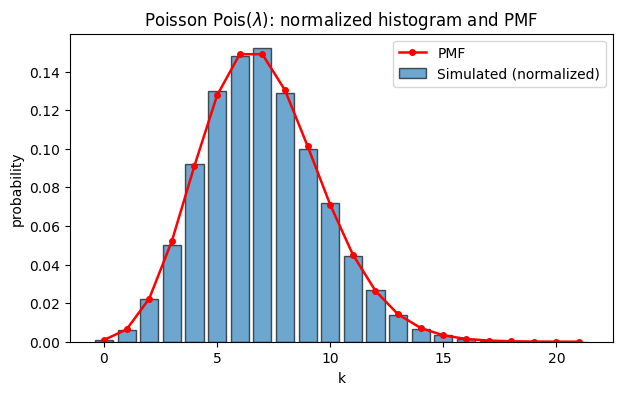

Sample mean: 6.9947 (theory 7.0000)
Sample variance: 6.9658 (theory 7.0000)


In [20]:

# Parameters
rng = np.random.default_rng(2024)
lmbda = 7.0
N = 120000

k_samples = rng.poisson(lam=lmbda, size=N)
mean_sample = np.mean(k_samples)
var_sample = np.var(k_samples)

# Empirical probabilities
vals, counts = np.unique(k_samples, return_counts=True)
probs_emp = counts / N

# Theoretical PMF using log-gamma for stability
k_min, k_max = int(np.min(vals)), int(np.max(vals))
ks = np.arange(k_min, k_max+1)
log_pmf = ks*np.log(lmbda) - lmbda - np.array([math.lgamma(k+1) for k in ks])
pmf = np.exp(log_pmf)

# Plot
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(vals, probs_emp, color='tab:blue', edgecolor='k', alpha=0.65, label='Simulated (normalized)')
ax.plot(ks, pmf, 'r-o', ms=4, lw=1.8, label='PMF')

ax.set_title(r'Poisson $\mathrm{Pois}(\lambda)$: normalized histogram and PMF')
ax.set_xlabel('k')
ax.set_ylabel('probability')
ax.legend()
plt.show()

print(f"Sample mean: {mean_sample:.4f} (theory {lmbda:.4f})")
print(f"Sample variance: {var_sample:.4f} (theory {lmbda:.4f})")



## Binomial Distribution (Discrete)
If $K \sim \mathrm{Bin}(n,p)$, the PMF is

$ P(K=k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k=0,1,\dots,n $

The mean is $\mathbb{E}[K] = np$ and the variance is $\mathrm{Var}(K) = np(1-p)$.



**Background and interpretation.** The binomial counts the number of **successes** in $n$ independent **Bernoulli** trials with success probability $p$ per trial. It applies when the number of trials is fixed in advance and each trial has the same $p$.  
**Approximations.** For large $n$ with moderate $p$, $K$ is well-approximated by a normal distribution $\mathcal{N}(np,\,np(1-p))$; for small $p$ and large $n$ with $np=\lambda$ moderate, $K$ is approximated by $\mathrm{Pois}(\lambda)$. Use a **continuity correction** when overlaying a continuous normal density on discrete counts.  
**Common physics uses.** Detection/non-detection in repeated measurements, coin-flip style experiments, and modeling the number of excited atoms after $n$ independent excitation attempts.


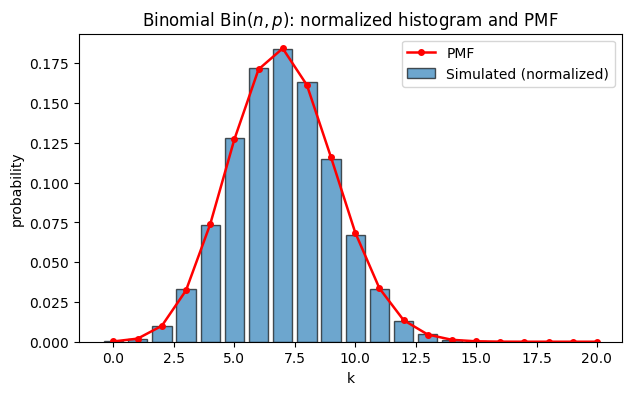

Sample mean: 6.9901 (theory 7.0000)
Sample variance: 4.5199 (theory 4.5500)


In [21]:

# Parameters
rng = np.random.default_rng(2024)
n, p = 20, 0.35
N = 120000

k_samples = rng.binomial(n=n, p=p, size=N)
mean_sample = np.mean(k_samples)
var_sample = np.var(k_samples)

# Empirical probabilities
vals, counts = np.unique(k_samples, return_counts=True)
probs_emp = counts / N

# Theoretical PMF using log-gamma for stability
ks = np.arange(0, n+1)
log_binom_coeff = np.array([math.lgamma(n+1) - math.lgamma(k+1) - math.lgamma(n-k+1) for k in ks])
log_pmf = log_binom_coeff + ks*np.log(p) + (n-ks)*np.log(1-p)
pmf = np.exp(log_pmf)

# Plot (align the bars at integer centers)
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(vals, probs_emp, color='tab:blue', edgecolor='k', alpha=0.65, label='Simulated (normalized)')
ax.plot(ks, pmf, 'r-o', ms=4, lw=1.8, label='PMF')

ax.set_title(r'Binomial $\mathrm{Bin}(n,p)$: normalized histogram and PMF')
ax.set_xlabel('k')
ax.set_ylabel('probability')
ax.legend()
plt.show()

print(f"Sample mean: {mean_sample:.4f} (theory {n*p:.4f})")
print(f"Sample variance: {var_sample:.4f} (theory {n*p*(1-p):.4f})")



## Maxwell–Boltzmann Speed Distribution
For a gas of non-interacting particles in thermal equilibrium (3D), the speed $v = \|\vec{v}\|$ follows the Maxwell–Boltzmann distribution:

$ f(v) = 4\pi \left( \dfrac{m}{2\pi k_B T} \right)^{3/2} v^2 e^{-\frac{m v^2}{2 k_B T}}, \quad v \ge 0 $

Characteristic speeds:

$ v_{\mathrm{mp}} = \sqrt{\dfrac{2 k_B T}{m}}, \quad v_{\mathrm{mean}} = \sqrt{\dfrac{8 k_B T}{\pi m}}, \quad v_{\mathrm{rms}} = \sqrt{\dfrac{3 k_B T}{m}}. $

**How to sample:** Draw $v_x, v_y, v_z \sim \mathcal{N}(0, \sigma^2)$ with $\sigma^2 = k_B T / m$ and set $ v = \sqrt{v_x^2 + v_y^2 + v_z^2} $. This produces the correct Maxwell–Boltzmann speed distribution.



**Background and interpretation.** In kinetic theory, each Cartesian velocity component of a particle in an ideal gas is Gaussian with mean $0$ and variance $\sigma^2=\dfrac{k_B T}{m}$. The **speed** $v=\sqrt{v_x^2+v_y^2+v_z^2}$ therefore follows a **chi distribution with three degrees of freedom**, yielding the Maxwell–Boltzmann speed density above. The distribution broadens with temperature ($T\uparrow$) and narrows with particle mass ($m\uparrow$).  
**Characteristic speeds.** The most probable speed $v_{\mathrm{mp}}$ maximizes $f(v)$, the mean speed $v_{\mathrm{mean}}$ averages speeds, and the root-mean-square speed $v_{\mathrm{rms}}$ relates to average kinetic energy via $\tfrac{1}{2} m v_{\mathrm{rms}}^2 = \tfrac{3}{2} k_B T$.  
**Limitations.** At very low temperatures or high densities, quantum statistics (Bose–Einstein or Fermi–Dirac) replace the classical Maxwell–Boltzmann picture; interactions and non-equilibrium conditions also invalidate the model.


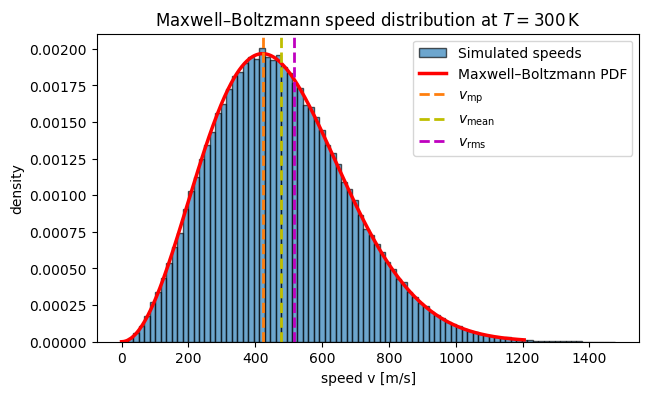

Theoretical v_mp:       422.08 m/s
Theoretical v_mean:     476.26 m/s | Sample mean:     477.17 m/s
Theoretical v_rms:      516.94 m/s | Sample rms:      518.02 m/s


In [28]:

# Maxwell–Boltzmann speeds: simulate and compare with analytic PDF
rng = np.random.default_rng(2024)

k_B = 1.380649e-23  # Boltzmann constant [J/K]
T = 300.0           # temperature [K]
# Approximate mass of an N2 molecule (~28 amu)
m = 4.65e-26        # [kg]

sigma = math.sqrt(k_B*T/m)  # std dev per component
N = 200000

vx = rng.normal(0.0, sigma, size=N)
vy = rng.normal(0.0, sigma, size=N)
vz = rng.normal(0.0, sigma, size=N)
v = np.sqrt(vx*vx + vy*vy + vz*vz)

# Analytic PDF
v_max = np.quantile(v, 0.999)
xs = np.linspace(0.0, v_max, 600)
pref = 4*np.pi * (m/(2*np.pi*k_B*T))**1.5
pdf = pref * xs**2 * np.exp(-m*xs**2/(2*k_B*T))

# Characteristic speeds
v_mp = math.sqrt(2*k_B*T/m)
v_mean = math.sqrt(8*k_B*T/(np.pi*m))
v_rms = math.sqrt(3*k_B*T/m)

mean_sample = np.mean(v)
rms_sample = math.sqrt(np.mean(v*v))

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(v, bins=90, density=True, alpha=0.65, color='tab:blue', edgecolor='k', label='Simulated speeds')
ax.plot(xs, pdf, 'r-', lw=2.5, label='Maxwell–Boltzmann PDF')

ax.axvline(v_mp, color='tab:orange', ls='--', lw=2, label=r'$v_{\mathrm{mp}}$')
ax.axvline(v_mean, color='y', ls='--', lw=2, label=r'$v_{\mathrm{mean}}$')
ax.axvline(v_rms, color='m', ls='--', lw=2, label=r'$v_{\mathrm{rms}}$')

ax.set_title(r'Maxwell–Boltzmann speed distribution at $T=300\,\mathrm{K}$')
ax.set_xlabel('speed v [m/s]')
ax.set_ylabel('density')
ax.legend()
plt.show()

print(f"Theoretical v_mp:   {v_mp:10.2f} m/s")
print(f"Theoretical v_mean: {v_mean:10.2f} m/s | Sample mean: {mean_sample:10.2f} m/s")
print(f"Theoretical v_rms:  {v_rms:10.2f} m/s | Sample rms:  {rms_sample:10.2f} m/s")



## Physics Example: Radioactive Decay Times
For a nucleus with decay constant $\lambda$, the waiting time to decay is exponentially distributed:

$ P(T \le t) = 1 - e^{-\lambda t}, \quad f_T(t) = \lambda e^{-\lambda t} $

The **half-life** $t_{1/2}$ satisfies $P(T \le t_{1/2}) = 1/2$, giving

$ t_{1/2} = \dfrac{\ln 2}{\lambda}. $

We'll simulate decay times for many nuclei and verify that the empirical distribution matches the exponential PDF.


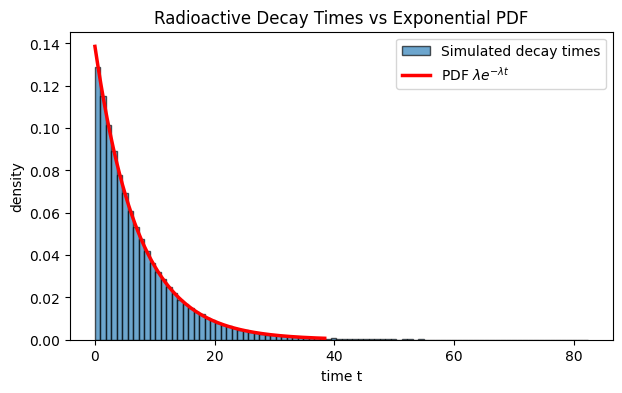

Half-life input: 5.000
Lambda used: 0.138629
Mean simulated time: 7.2220 (theory 7.2135)


In [26]:

# Parameters
rng = np.random.default_rng(2024)
half_life = 5.0  # arbitrary time units
lmbda = math.log(2.0)/half_life
N = 150000

# Simulate decay times
T = rng.exponential(scale=1.0/lmbda, size=N)

# Plot histogram and overlay PDF
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(T, bins=90, density=True, alpha=0.65, edgecolor='k', color='tab:blue', label='Simulated decay times')

xs = np.linspace(0, np.quantile(T, 0.995), 600)
pdf = lmbda*np.exp(-lmbda*xs)
ax.plot(xs, pdf, 'r-', lw=2.5, label=r'PDF $\lambda e^{-\lambda t}$')

ax.set_title('Radioactive Decay Times vs Exponential PDF')
ax.set_xlabel('time t')
ax.set_ylabel('density')
ax.legend()
plt.show()

print(f"Half-life input: {half_life:.3f}")
print(f"Lambda used: {lmbda:.6f}")
print(f"Mean simulated time: {np.mean(T):.4f} (theory {1/lmbda:.4f})")



## Practical Tips and Best Practices
- Prefer the modern API: `rng = np.random.default_rng(seed)` and then `rng.normal`, `rng.uniform`, etc.
- For **reproducibility**: record your seed(s) and the sequence of operations. Keep RNG state local when possible.
- For **histograms**: use a sufficient number of samples and bins. For continuous distributions, set `density=True` to compare with PDFs.
- When comparing simulation with theory, ensure you use the correct parameters (e.g., NumPy's exponential uses `scale = 1/\lambda`).
- For **discrete** distributions, compare **probabilities** (normalized counts) with the **PMF**.
- For numerical stability when computing PMFs, work in log-space and use $\ln(\Gamma(\cdot))$ (via `math.lgamma`).



## Exercises
1. **Central Limit Theorem (CLT)**: Generate $M$ independent samples of the average of $n$ i.i.d. uniform random variables. Show that as $n$ increases, the distribution of the averages approaches a normal distribution with mean $\mu = \dfrac{a+b}{2}$ and standard deviation $\sigma/\sqrt{n}$ where $\sigma^2 = \dfrac{(b-a)^2}{12}$.
2. **Poisson Process Inter-Arrival Times**: For a Poisson process with rate $\lambda$, simulate inter-arrival times using $X \sim \mathrm{Exp}(\lambda)$. Verify that the sum of $k$ inter-arrival times has the Gamma distribution with shape $k$ and rate $\lambda$ (hint: histogram and overlay the Gamma PDF $ f(t) = \dfrac{\lambda^k t^{k-1} e^{-\lambda t}}{\Gamma(k)} $).
3. **Binomial-to-Normal Approximation**: For large $n$ and moderate $p$, demonstrate that $\mathrm{Bin}(n,p)$ is well-approximated by $\mathcal{N}(np, np(1-p))$ by overlaying the normal PDF on the discrete histogram (with a continuity correction).
4. **Random Walk (Diffusion)**: Simulate a 1D random walk with step distribution $\mathcal{N}(0, \sigma^2)$ and show that position after $N$ steps has variance $N\sigma^2$. Plot histograms of the final position for different $N$ and compare with the predicted normal.
5. **Inverse-Transform Sampling Practice**: Starting from $U \sim U(0,1)$, derive and implement the inverse CDF sampler for the Cauchy distribution with location $x_0$ and scale $\gamma$: $ X = x_0 + \gamma \tan\!\left[\pi\,(U - 1/2)\right] $. Compare histogram with the analytic PDF $ f(x) = \dfrac{1}{\pi \gamma} \dfrac{\gamma^2}{(x-x_0)^2 + \gamma^2} $.
